# COMP6010 C2 — Continue to 500 epochs and test EMA
**Sayuru Bopitiya · 24071158**

A bounded follow-up after the 250-epoch run and its calibrated evaluation (10/64 recognisable at 50 steps; 11/64 at 20 steps). These results motivated this experiment; it is not the originally planned experiment.

Compare **250 epochs / ordinary weights**, **500 / ordinary weights**, and **500 / EMA weights**, all with **50 Euler steps**. Keep the original 2,400/600 split, network, optimizer settings and training seed unchanged. Initialise EMA at epoch 250; update it after every subsequent optimizer step with decay 0.999. No scheduler, augmentation, filtering or architecture change is introduced.

**One final bounded attempt:** stop at 500 epochs. A suggested practical improvement rule is a gain of at least 10 percentage points (at least 7 additional successes out of 64) over the freshly evaluated 250-epoch baseline, with a paired 95% bootstrap interval above zero. This working rule is not an assignment requirement or proof of generalisable improvement. It is fixed before new outputs are generated. If neither final model meets it, move to the report and discuss the weak quality honestly.

**How to run:** select a GPU using **Runtime → Change runtime type → GPU**. Run all cells. Cell 2 uses your saved Drive checkpoint, or asks for **cat_250_v1_results.zip** / the original full supplement. A disconnected runtime resumes from Drive by rerunning the notebook with the same run name. Checkpoints save every five epochs, so up to four epochs may need to repeat.

After training and generation, **score all 192 shuffled images in Cell 9**. Then rerun **Cells 10–12** and upload the final results ZIP plus this notebook saved **with outputs** (File → Download → .ipynb). Run-all may export an incomplete progress ZIP before you have scored the images; this is expected. Only an export marked **COMPLETE_FOR_REVIEW** has current quality analysis.

Prediction fields in Cell 4 are optional. Blank fields are recorded as missing, never invented, and do not interrupt training. Your previous prediction record remains part of the existing assignment evidence.

## Cell 1 — Setup and fixed settings
Keep these settings for this first run. Google Drive saves both training and ratings. Set an explicit checkpoint path only if needed. No paid compute is requested by this notebook.

In [1]:
from pathlib import Path
from datetime import datetime,timezone
import copy,hashlib,importlib.metadata,io,json,math,os,platform,shutil,sys,time,urllib.request,zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader,TensorDataset
from scipy.stats import binomtest
from IPython.display import display,clear_output

SAVE_TO_DRIVE=True
REQUIRE_GPU=True
RUN_NAME='cat_500_ema_v1'
SOURCE_CHECKPOINT=''  # Optional full path to the original checkpoint_epoch_250.pt.
SOURCE_EPOCH=250
TARGET_EPOCH=500
EMA_DECAY=0.999
SAVE_INTERVAL=5
SAVE_EPOCHS=[350,500]
TRAIN_SEED=2026
N_SELECTED=3000
TRAIN_FRACTION=0.8
SPLIT_SEED=6010
BATCH_SIZE=64
LEARNING_RATE=2e-4
WEIGHT_DECAY=1e-4
STEPS=50
INFERENCE_BATCH=16
TIMING_REPEATS=5
DEV_SEEDS=list(range(38001,38017))
EVALUATION_SEEDS=list(range(39001,39065))
SHUFFLE_SEED=601050
BOOTSTRAP_SEED=601051
BOOTSTRAP_REPEATS=20000
MAJOR_GAIN=0.10
CONFIGS=[('epoch250_raw',250,'model'),('epoch500_raw',500,'model'),('epoch500_ema',500,'ema')]
EXPECTED_SOURCE_CHECKPOINT_SHA256='a4907f275c56b23c43288b76e96fdbfa59666f2f548b67d5696f02a6b512c13e'
EXPECTED_DATA_SHA256='21a281839d3f2eef601d57d2338a4eafdf24649f8d0a0e42d3ec3e595911463e'
EXPECTED_MANIFEST_SHA256='0afa1da4fc9a7e10d8836970e8e8d5ab6ffdb977f68a39b94aa7552d115cfaec'
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if REQUIRE_GPU and DEVICE.type!='cuda':
    raise RuntimeError('Select Runtime > Change runtime type > GPU, then rerun. No GPU is currently connected.')
torch.set_num_threads(min(4,os.cpu_count() or 1))
torch.backends.cudnn.benchmark=False
torch.backends.cudnn.deterministic=True
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE=Path('/content/drive/MyDrive/COMP6010')
else:BASE=Path.cwd()/'COMP6010'
RUN=BASE/RUN_NAME;RUN.mkdir(parents=True,exist_ok=True)
CACHE=Path('/content/comp6010_data') if Path('/content').exists() else Path.cwd()/'comp6010_data'
CACHE.mkdir(parents=True,exist_ok=True)
VERSIONS={p:importlib.metadata.version(p) for p in ['torch','numpy','pandas','matplotlib','scipy']}
HARDWARE=torch.cuda.get_device_name(0) if DEVICE.type=='cuda' else platform.processor()
def utc_now():return datetime.now(timezone.utc).isoformat()
def save_json(path,value):
    path=Path(path);tmp=path.with_suffix(path.suffix+'.tmp')
    tmp.write_text(json.dumps(value,indent=2));os.replace(tmp,path)
def save_csv(path,frame):
    path=Path(path);tmp=path.with_suffix(path.suffix+'.tmp')
    frame.to_csv(tmp,index=False);os.replace(tmp,path)
def atomic_torch_save(payload,path):
    path=Path(path);tmp=path.with_suffix(path.suffix+'.tmp')
    torch.save(payload,tmp);os.replace(tmp,path)
def synchronize():
    if DEVICE.type=='cuda':torch.cuda.synchronize()
print('Device:',DEVICE,'| Hardware:',HARDWARE,'| Versions:',VERSIONS)
print('Saved run:',RUN)

Mounted at /content/drive
Device: cuda | Hardware: NVIDIA A100-SXM4-40GB | Versions: {'torch': '2.11.0+cu128', 'numpy': '2.1.3', 'pandas': '2.2.3', 'matplotlib': '3.10.0', 'scipy': '1.16.3'}
Saved run: /content/drive/MyDrive/COMP6010/cat_500_ema_v1


## Cell 2 — Restore and verify the original checkpoint
Recovery accepts the original results/supplement ZIP, a standalone original epoch-250 checkpoint, or this notebook's later results ZIP. The original checkpoint must match the previously reviewed hash. A bad or different file cannot silently become the baseline. Continuation files are restored only into this separate run folder.

In [2]:
from pathlib import Path
import hashlib, os, shutil, zipfile
import numpy as np
import pandas as pd
import torch

def digest(path):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''):h.update(block)
    return h.hexdigest()

def restore_verified_member(archive,basename,target,expected_hash):
    target=Path(target);target.parent.mkdir(parents=True,exist_ok=True)
    temporary=target.with_suffix(target.suffix+'.restore_tmp')
    with zipfile.ZipFile(archive) as z:
        for member in z.infolist():
            p=Path(member.filename)
            if p.is_absolute() or '..' in p.parts or p.name!=basename:continue
            with z.open(member) as inp,open(temporary,'wb') as out:shutil.copyfileobj(inp,out)
            if digest(temporary)==expected_hash:
                os.replace(temporary,target)
                return member.filename
    temporary.unlink(missing_ok=True)
    raise ValueError('The ZIP does not contain the verified original '+basename)

@torch.no_grad()
def update_ema(ema,raw,decay):
    if not 0<=decay<1:raise ValueError('EMA decay must lie in [0, 1).')
    for average,current in zip(ema.parameters(),raw.parameters(),strict=True):
        average.mul_(decay).add_(current,alpha=1-decay)
    # GroupNorm needs no running-statistics update; copy the fixed frequency buffer.
    for average,current in zip(ema.buffers(),raw.buffers(),strict=True):average.copy_(current)

def validate_continuation(checkpoint,run_id,source_epoch,batches_per_epoch):
    epoch=checkpoint.get('epoch',-1)
    if checkpoint.get('run_id')!=run_id or epoch<source_epoch:
        raise ValueError('Checkpoint belongs to a different continuation experiment.')
    if checkpoint.get('ema_start_epoch')!=source_epoch or 'ema' not in checkpoint:
        raise ValueError('EMA history is missing; do not silently initialise a new average.')
    if checkpoint.get('ema_updates')!=(epoch-source_epoch)*batches_per_epoch:
        raise ValueError('EMA update count does not match the saved epoch.')
    history=checkpoint.get('history',[])
    if [row.get('epoch') for row in history]!=list(range(1,epoch+1)):
        raise ValueError('Training history is incomplete or duplicated.')
    if 'model' not in checkpoint or 'optimizer' not in checkpoint:
        raise ValueError('Model or optimizer state is missing.')
    return epoch

def validate_ratings(frame,key):
    if len(frame)!=len(key) or frame.image_id.duplicated().any() or set(frame.image_id)!=set(key.image_id):
        raise ValueError('Every anonymous ID must occur exactly once.')
    scores=pd.to_numeric(frame.cat_score,errors='coerce')
    if scores.isna().any() or not scores.isin([0,1,2]).all():
        raise ValueError('Finish every rating with a score of 0, 1, or 2.')
    if frame.rater.astype(str).str.strip().eq('').any():raise ValueError('Every rating needs a rater name.')
    if pd.to_datetime(frame.rated_utc,utc=True,errors='coerce').isna().any():raise ValueError('Every rating needs a valid timestamp.')
    result=frame.copy();result['cat_score']=scores.astype(int)
    return result.merge(key,on='image_id',validate='one_to_one')

def paired_difference(a,b,seed=601051,repeats=20000):
    a,b=np.asarray(a,dtype=float),np.asarray(b,dtype=float)
    if a.shape!=b.shape or a.ndim!=1 or not len(a) or not np.isfinite(a-b).all():
        raise ValueError('Finite, matched, nonempty vectors are required.')
    d=a-b
    indices=np.random.default_rng(seed).integers(0,len(d),size=(repeats,len(d)))
    lo,hi=np.quantile(d[indices].mean(axis=1),[0.025,0.975])
    return {'difference':float(d.mean()),'ci95_low':float(lo),'ci95_high':float(hi),
            'improved_seeds':int((d>0).sum()),'tied_seeds':int((d==0).sum()),
            'worsened_seeds':int((d<0).sum()),'degenerate_bootstrap':bool(np.ptp(d)==0)}


SOURCE_PATH=RUN/'source_checkpoint_epoch250.pt'
if not SOURCE_PATH.exists() or digest(SOURCE_PATH)!=EXPECTED_SOURCE_CHECKPOINT_SHA256:
    candidates=[Path(SOURCE_CHECKPOINT)] if SOURCE_CHECKPOINT.strip() else []
    candidates += [BASE/'cat_250_v1'/'checkpoint_epoch_250.pt',
                   BASE/'cat_eval64_v1'/'restored_checkpoints'/'checkpoint_epoch_250.pt']
    found=next((p for p in candidates if p.is_file() and digest(p)==EXPECTED_SOURCE_CHECKPOINT_SHA256),None)
    if found is not None:shutil.copy2(found,SOURCE_PATH)
    else:
        from google.colab import files
        print('Upload cat_250_v1_results.zip, the original supplement ZIP, checkpoint_epoch_250.pt, or cat_500_ema_v1_results.zip to recover progress.')
        uploaded=files.upload()
        if len(uploaded)!=1:raise ValueError('Upload exactly one checkpoint or results ZIP.')
        filename,content=next(iter(uploaded.items()))
        if filename.lower().endswith('.pt'):
            if hashlib.sha256(content).hexdigest()!=EXPECTED_SOURCE_CHECKPOINT_SHA256:
                raise ValueError('This is not the reviewed epoch-250 checkpoint.')
            temporary=SOURCE_PATH.with_suffix('.restore_tmp');temporary.write_bytes(content);os.replace(temporary,SOURCE_PATH)
        elif filename.lower().endswith('.zip'):
            stream=io.BytesIO(content)
            with zipfile.ZipFile(stream) as z:
                names=z.namelist()
                is_continuation='protocol.json' in names and 'source_checkpoint_epoch250.pt' in names
                if is_continuation:
                    archived_protocol=json.loads(z.read('protocol.json'))
                    if archived_protocol['settings']['source_checkpoint_sha256']!=EXPECTED_SOURCE_CHECKPOINT_SHA256:
                        raise ValueError('This continuation archive has a different starting checkpoint.')
                    if (RUN/'protocol.json').exists() and json.loads((RUN/'protocol.json').read_text())!=archived_protocol:
                        raise ValueError('Existing run and uploaded archive have different protocols. Preserve both with separate run names.')
                    if (RUN/'last_checkpoint.pt').exists():
                        raise ValueError('A saved continuation already exists. Use the current Drive folder instead of overwriting it from a ZIP.')
                    if sum(m.file_size for m in z.infolist())>300*1024*1024:
                        raise ValueError('Unexpectedly large continuation archive.')
                    for member in z.infolist():
                        p=Path(member.filename)
                        if p.is_absolute() or '..' in p.parts or '\\' in member.filename:
                            raise ValueError('Unsafe path in continuation archive.')
                        if member.is_dir():continue
                        destination=RUN/p;destination.parent.mkdir(parents=True,exist_ok=True)
                        tmp=destination.with_suffix(destination.suffix+'.restore_tmp')
                        with z.open(member) as inp,open(tmp,'wb') as out:shutil.copyfileobj(inp,out)
                        os.replace(tmp,destination)
                    print('Restored continuation, EMA state, and saved evaluation progress.')
                else:
                    stream.seek(0)
                    restore_verified_member(stream,'checkpoint_epoch_250.pt',SOURCE_PATH,EXPECTED_SOURCE_CHECKPOINT_SHA256)
        else:raise ValueError('Upload a .pt checkpoint or .zip results archive.')
        del uploaded,content
if digest(SOURCE_PATH)!=EXPECTED_SOURCE_CHECKPOINT_SHA256:raise ValueError('Original checkpoint hash verification failed.')
if not (RUN/'last_checkpoint.pt').exists() and (RUN/f'checkpoint_epoch_{TARGET_EPOCH}.pt').exists():
    shutil.copy2(RUN/f'checkpoint_epoch_{TARGET_EPOCH}.pt',RUN/'last_checkpoint.pt')
SOURCE_CP=torch.load(SOURCE_PATH,map_location='cpu',weights_only=True)
if SOURCE_CP['epoch']!=SOURCE_EPOCH or len(SOURCE_CP['history'])!=SOURCE_EPOCH or 'optimizer' not in SOURCE_CP:
    raise ValueError('Starting checkpoint must include epoch-250 model, optimizer, and full history.')
print('Verified original epoch-250 checkpoint; original experiment is preserved.')

Verified original epoch-250 checkpoint; original experiment is preserved.


## Cell 3 — Recreate the exact dataset split and network
The 3,000 selected originals, duplicate handling, 2,400/600 split and normalisation must reproduce the previous manifest. The 600 held-out drawings are a repeatedly consulted development set, not a new independent test set. Dataset download is approximately 92 MiB. The full public dataset is cached but is excluded from results exports.

In [3]:
DATA_URL='https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/cat.npy'
DATA_FILE=CACHE/'cat.npy'
def sha256_file(path):
    digest=hashlib.sha256()
    with open(path,'rb') as handle:
        for block in iter(lambda:handle.read(1024*1024),b''):
            digest.update(block)
    return digest.hexdigest()

if not DATA_FILE.exists():
    temporary=DATA_FILE.with_suffix('.download')
    print('Downloading the public cat bitmap file...')
    with urllib.request.urlopen(DATA_URL,timeout=120) as response,open(temporary,'wb') as handle:
        shutil.copyfileobj(response,handle)
    # Validate before naming the cache file as complete.
    check=np.load(temporary,mmap_mode='r',allow_pickle=False)
    assert check.ndim==2 and check.shape[1]==784
    del check
    os.replace(temporary,DATA_FILE)
source_hash=sha256_file(DATA_FILE)
if source_hash!=EXPECTED_DATA_SHA256:raise ValueError('Public dataset bytes changed; preserve the original source before continuing.')
all_images=np.load(DATA_FILE,mmap_mode='r',allow_pickle=False)
if all_images.shape!=(123202,784):raise ValueError('Unexpected dataset shape.')
assert all_images.dtype==np.uint8 and all_images.shape[1]==784
split_rng=np.random.default_rng(SPLIT_SEED)
selected_indices=split_rng.choice(len(all_images),size=N_SELECTED,replace=False)
bitmaps=np.array(all_images[selected_indices])
hashes=[hashlib.sha256(row.tobytes()).hexdigest() for row in bitmaps]
seen=set()
keep=[]
for i,h in enumerate(hashes):
    if h not in seen:
        seen.add(h)
        keep.append(i)
keep=np.array(keep,dtype=int)
permuted=split_rng.permutation(keep)
cut=int(TRAIN_FRACTION*len(permuted))
train_positions,eval_positions=permuted[:cut],permuted[cut:]
assert len(train_positions)>BATCH_SIZE and len(eval_positions)>0
split_labels=np.full(N_SELECTED,'excluded_exact_duplicate',dtype=object)
split_labels[train_positions]='train'
split_labels[eval_positions]='held_out'
manifest=pd.DataFrame({'source_row_index':selected_indices,'bitmap_sha256':hashes,'split':split_labels})
assert not set(manifest.loc[manifest.split=='train','bitmap_sha256']) & set(manifest.loc[manifest.split=='held_out','bitmap_sha256'])
manifest.to_csv(RUN/'data_manifest.csv',index=False)
data_info={'source_url':DATA_URL,'source_sha256':source_hash,'source_rows':len(all_images),
           'category':'cat','license':'CC BY 4.0','selected_original_rows':N_SELECTED,
           'duplicates_removed':N_SELECTED-len(keep),'train_originals':len(train_positions),
           'held_out_originals':len(eval_positions),'split_seed':SPLIT_SEED,
           'preprocessing':'uint8/127.5 - 1; reshape to 1x28x28; no augmentation; no aesthetic filtering'}
(RUN/'data_source.json').write_text(json.dumps(data_info,indent=2))
train_x=torch.from_numpy(bitmaps[train_positions].astype(np.float32)/127.5-1).reshape(-1,1,28,28)
eval_x=torch.from_numpy(bitmaps[eval_positions].astype(np.float32)/127.5-1).reshape(-1,1,28,28)
print(json.dumps(data_info,indent=2))
print('Tensor shapes:',train_x.shape,eval_x.shape)

class TimeEmbedding(nn.Module):
    def __init__(self,dimension=64):
        super().__init__()
        self.register_buffer('frequencies',torch.exp(-math.log(10000)*torch.arange(dimension//2)/(dimension//2-1)))
        self.mlp=nn.Sequential(nn.Linear(dimension,128),nn.SiLU(),nn.Linear(128,128))
    def forward(self,t):
        angles=t[:,None]*self.frequencies[None,:]*1000
        return self.mlp(torch.cat([angles.sin(),angles.cos()],dim=1))

class TimeBlock(nn.Module):
    def __init__(self,input_channels,output_channels):
        super().__init__()
        self.conv1=nn.Conv2d(input_channels,output_channels,3,padding=1)
        self.norm1=nn.GroupNorm(8,output_channels)
        self.time=nn.Linear(128,output_channels)
        self.conv2=nn.Conv2d(output_channels,output_channels,3,padding=1)
        self.norm2=nn.GroupNorm(8,output_channels)
        self.skip=nn.Conv2d(input_channels,output_channels,1) if input_channels!=output_channels else nn.Identity()
    def forward(self,x,time_embedding):
        h=F.silu(self.norm1(self.conv1(x)))
        h=h+self.time(time_embedding)[:,:,None,None]
        h=self.norm2(self.conv2(F.silu(h)))
        return F.silu(h+self.skip(x))

class VelocityUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.time=TimeEmbedding()
        self.input=nn.Conv2d(1,32,3,padding=1)
        self.block28=TimeBlock(32,32)
        self.down14=nn.Conv2d(32,64,4,stride=2,padding=1)
        self.block14=TimeBlock(64,64)
        self.down7=nn.Conv2d(64,128,4,stride=2,padding=1)
        self.middle=TimeBlock(128,128)
        self.up14=TimeBlock(128+64,64)
        self.up28=TimeBlock(64+32,32)
        self.output=nn.Conv2d(32,1,3,padding=1)
    def forward(self,x,t):
        embedding=self.time(t)
        skip28=self.block28(self.input(x),embedding)
        skip14=self.block14(self.down14(skip28),embedding)
        h=self.middle(self.down7(skip14),embedding)
        h=self.up14(torch.cat([F.interpolate(h,size=(14,14),mode='nearest'),skip14],dim=1),embedding)
        h=self.up28(torch.cat([F.interpolate(h,size=(28,28),mode='nearest'),skip28],dim=1),embedding)
        return self.output(h)

manifest_digest=hashlib.sha256(manifest.to_csv(index=False).encode()).hexdigest()
if manifest_digest!=EXPECTED_MANIFEST_SHA256:raise ValueError('Dataset split differs from the original reviewed manifest.')
TRAINING_ID={'architecture':'VelocityUNet_v1_32_64_128','manifest_sha256':manifest_digest,
             'source_sha256':source_hash,'train_seed':TRAIN_SEED,'batch_size':BATCH_SIZE,
             'learning_rate':LEARNING_RATE,'weight_decay':WEIGHT_DECAY}
if SOURCE_CP['training_id']!=TRAINING_ID:raise ValueError('Original training identity and current data/settings differ.')
BATCHES_PER_EPOCH=math.ceil(len(train_x)/BATCH_SIZE)
assert len(train_x)==2400 and len(eval_x)==600 and BATCHES_PER_EPOCH==38
assert sum(p.numel() for p in VelocityUNet().parameters())==819521
print('Verified: original manifest, training identity, network, and 38 optimizer updates per epoch.')

{
  "source_url": "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/cat.npy",
  "source_sha256": "21a281839d3f2eef601d57d2338a4eafdf24649f8d0a0e42d3ec3e595911463e",
  "source_rows": 123202,
  "category": "cat",
  "license": "CC BY 4.0",
  "selected_original_rows": 3000,
  "duplicates_removed": 0,
  "train_originals": 2400,
  "held_out_originals": 600,
  "split_seed": 6010,
  "preprocessing": "uint8/127.5 - 1; reshape to 1x28x28; no augmentation; no aesthetic filtering"
}
Tensor shapes: torch.Size([2400, 1, 28, 28]) torch.Size([600, 1, 28, 28])
Verified: original manifest, training identity, network, and 38 optimizer updates per epoch.


## Cell 4 — Lock this follow-up protocol; optional personal prediction
You may enter predictions in your own words before training. Leaving them blank is permitted and is explicitly recorded as missing. The assistant's hypotheses below are labelled suggestions, not your personal predictions. On resume, the saved protocol is reused and will not be backdated or overwritten.

The scoring rubric is the calibrated rubric you used in the second rating pass. Do not change it after seeing the new outputs. Development seeds and final evaluation seeds are disjoint; the original 16- and 64-seed results are not pooled with these new results.

In [4]:
MY_TRAINING_PREDICTION=''  # Optional: what do you expect from epoch 500 versus 250, and why?
MY_EMA_PREDICTION=''       # Optional: what do you expect from EMA versus ordinary epoch-500 weights?
PRIOR_CONTEXT='I have seen the original training results and both rating passes of the previous 64-seed evaluation.'
RUBRIC={'0':'No identifiable animal structure; blank, noise, or disconnected marks.',
        '1':'Animal-like or cat-like features, but the overall animal identity is ambiguous or incoherent.',
        '2':'Recognisable cat with coherent overall identifying structure. A rough head-only drawing can qualify; pointy ears alone are insufficient. No artistic polish or symmetry requirement.'}
settings={'version':1,'source_checkpoint_sha256':EXPECTED_SOURCE_CHECKPOINT_SHA256,'training_id':TRAINING_ID,
          'source_epoch':SOURCE_EPOCH,'target_epoch':TARGET_EPOCH,'ema_decay':EMA_DECAY,
          'ema_initialisation':'copy ordinary epoch-250 weights; average after each update during epochs 251-500 only',
          'development_seeds':DEV_SEEDS,'evaluation_seeds':EVALUATION_SEEDS,'configurations':CONFIGS,
          'steps':STEPS,'inference_batch':INFERENCE_BATCH,'timing_repeats':TIMING_REPEATS,
          'shuffle_seed':SHUFFLE_SEED,'bootstrap_seed':BOOTSTRAP_SEED,'bootstrap_repeats':BOOTSTRAP_REPEATS,
          'primary_measure':'fraction scored 2','rubric':RUBRIC,'major_gain_margin':MAJOR_GAIN,
          'practical_screening_rule':'At least +0.10 recognisable fraction over epoch250_raw AND paired bootstrap 95% lower bound > 0.',
          'uncertainty_scope':'One trained model trajectory, 64 sampled seeds and one rater; no training-seed or inter-rater inference. Exploratory intervals, no multiple-comparison adjustment.',
          'stopping_rule':'Stop training at 500; if no major improvement by the fixed rule, proceed to the report.'}
settings=json.loads(json.dumps(settings))
protocol_path=RUN/'protocol.json'
if protocol_path.exists():
    protocol=json.loads(protocol_path.read_text())
    if protocol['settings']!=settings:raise ValueError('Saved protocol differs. Restore the original settings or choose a separate run name.')
    print('Reusing protocol recorded',protocol['recorded_utc'])
else:
    if (RUN/'last_checkpoint.pt').exists() or (RUN/'generation_complete.json').exists():
        raise ValueError('Existing training/evaluation state has no protocol. Recover the original protocol instead of recreating it.')
    protocol={'recorded_utc':utc_now(),'settings':settings,'prior_context':PRIOR_CONTEXT,
              'student_prediction_training':MY_TRAINING_PREDICTION.strip() or None,
              'student_prediction_ema':MY_EMA_PREDICTION.strip() or None,
              'assistant_hypotheses':{'training':'Extra training may help, but the recent loss gains are small and recognisability may remain weak.',
                                      'ema':'EMA may stabilise weights; a quality benefit is uncertain and must be measured.'}}
    save_json(protocol_path,protocol)
RUN_ID={'protocol_sha256':digest(protocol_path),'training_id':TRAINING_ID,
        'source_checkpoint_sha256':EXPECTED_SOURCE_CHECKPOINT_SHA256,'source_epoch':SOURCE_EPOCH,
        'target_epoch':TARGET_EPOCH,'ema_decay':EMA_DECAY}
save_json(RUN/'configuration.json',{'run_id':RUN_ID,'parameter_count':819521,
    'save_interval_epochs':SAVE_INTERVAL,'data':data_info,'versions_this_session':VERSIONS,
    'python':sys.version,'hardware_this_session':HARDWARE,'device_this_session':str(DEVICE)})
print('Protocol locked. Optional missing predictions:',[k for k in ['student_prediction_training','student_prediction_ema'] if protocol[k] is None])

Protocol locked. Optional missing predictions: ['student_prediction_training', 'student_prediction_ema']


## Cell 5 — Continue training to 500, preserving optimizer and EMA state
EMA is an extra evaluation copy; the ordinary network receives exactly the existing training objective and optimizer settings. `ema ← 0.999 × ema + 0.001 × current_weights` follows each optimizer step. GroupNorm needs no batch-normalisation recalibration.

Checkpoints include ordinary weights, EMA weights, EMA update count, optimizer, history and protocol identity. Resume validates all of these. The fixed held-out loss uses the same noise/time seed 8801 as previously. Timing records separate training, two-model held-out evaluation, and checkpoint saving. Old training times were measured on a T4; new hardware is recorded, so do not interpret a sum as a single-hardware benchmark.

Starting after epoch 250 | preserved EMA updates: 0
Estimated remaining training + evaluation: 9.1 minutes, plus Drive saving.
Epoch 255/500: train=0.32377, raw held-out=0.33372, EMA held-out=0.33256; checkpoint saved (0.1s).
Epoch 260/500: train=0.32218, raw held-out=0.33339, EMA held-out=0.33148; checkpoint saved (0.1s).
Epoch 265/500: train=0.32295, raw held-out=0.33572, EMA held-out=0.33064; checkpoint saved (0.1s).
Epoch 270/500: train=0.32226, raw held-out=0.33384, EMA held-out=0.33006; checkpoint saved (0.1s).
Epoch 275/500: train=0.32429, raw held-out=0.33423, EMA held-out=0.32966; checkpoint saved (0.1s).
Epoch 280/500: train=0.31878, raw held-out=0.33348, EMA held-out=0.32936; checkpoint saved (0.1s).
Epoch 285/500: train=0.32024, raw held-out=0.33351, EMA held-out=0.32912; checkpoint saved (0.1s).
Epoch 290/500: train=0.32445, raw held-out=0.33403, EMA held-out=0.32894; checkpoint saved (0.1s).
Epoch 295/500: train=0.32346, raw held-out=0.33474, EMA held-out=0.32877; checkpo

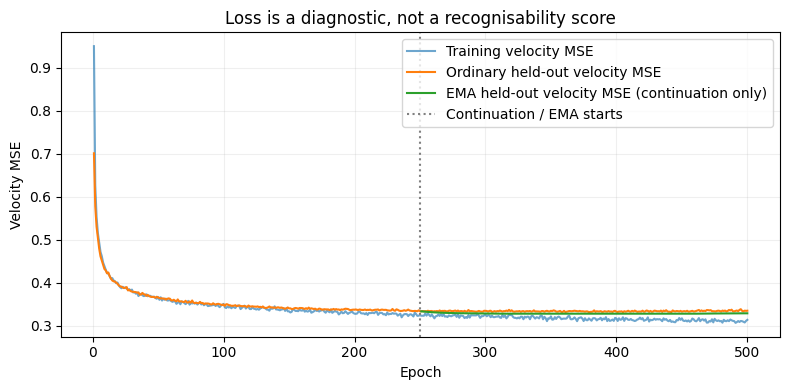

Training finished at epoch 500 | EMA updates: 9500


In [5]:
def make_training_pair(clean):
    noise=torch.randn_like(clean)
    t=torch.rand(len(clean),device=clean.device)
    mixed=(1-t[:,None,None,None])*noise+t[:,None,None,None]*clean
    return mixed,t,clean-noise

evaluation_rng=torch.Generator().manual_seed(8801)
eval_noise=torch.randn(eval_x.shape,generator=evaluation_rng)
eval_t=torch.rand(len(eval_x),generator=evaluation_rng)
eval_mixed=(1-eval_t[:,None,None,None])*eval_noise+eval_t[:,None,None,None]*eval_x
eval_target=eval_x-eval_noise

@torch.no_grad()
def held_out_loss(network):
    network.eval();total=0.0
    for begin in range(0,len(eval_x),BATCH_SIZE):
        end=begin+BATCH_SIZE
        prediction=network(eval_mixed[begin:end].to(DEVICE),eval_t[begin:end].to(DEVICE))
        total+=float(F.mse_loss(prediction,eval_target[begin:end].to(DEVICE)))*len(prediction)
    return total/len(eval_x)

# Same epoch seeds and data-loader seeds make completed-epoch resume independent of old RNG state.
torch.manual_seed(TRAIN_SEED)
model=VelocityUNet().to(DEVICE)
optimizer=torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
last_path=RUN/'last_checkpoint.pt'
if last_path.exists():
    checkpoint=torch.load(last_path,map_location='cpu',weights_only=True)
    start_epoch=validate_continuation(checkpoint,RUN_ID,SOURCE_EPOCH,BATCHES_PER_EPOCH)
    if checkpoint['history'][:SOURCE_EPOCH]!=SOURCE_CP['history']:
        raise ValueError('Continuation changed the original training history.')
    model.load_state_dict(checkpoint['model']);optimizer.load_state_dict(checkpoint['optimizer'])
    history=copy.deepcopy(checkpoint['history']);ema_updates=checkpoint['ema_updates']
    ema=copy.deepcopy(model).eval();ema.load_state_dict(checkpoint['ema'])
else:
    model.load_state_dict(SOURCE_CP['model']);optimizer.load_state_dict(copy.deepcopy(SOURCE_CP['optimizer']))
    history=copy.deepcopy(SOURCE_CP['history']);start_epoch=SOURCE_EPOCH;ema_updates=0
    ema=copy.deepcopy(model).eval()
for p in ema.parameters():p.requires_grad_(False)
for state in optimizer.state.values():
    for name,value in state.items():
        if torch.is_tensor(value):state[name]=value.to(DEVICE)
if start_epoch>TARGET_EPOCH:raise ValueError('Saved checkpoint is beyond the requested target epoch.')
print('Starting after epoch',start_epoch,'| preserved EMA updates:',ema_updates)

training_session_started=time.perf_counter()
for epoch in range(start_epoch+1,TARGET_EPOCH+1):
    torch.manual_seed(TRAIN_SEED+epoch)
    if DEVICE.type=='cuda':torch.cuda.manual_seed_all(TRAIN_SEED+epoch)
    loader=DataLoader(TensorDataset(train_x),batch_size=BATCH_SIZE,shuffle=True,num_workers=0,
                      generator=torch.Generator().manual_seed(TRAIN_SEED+10000+epoch))
    model.train();synchronize();started=time.perf_counter();loss_sum=0.0
    for (clean_cpu,) in loader:
        clean=clean_cpu.to(DEVICE);mixed,t,target=make_training_pair(clean)
        optimizer.zero_grad(set_to_none=True)
        loss=F.mse_loss(model(mixed,t),target)
        if not torch.isfinite(loss):raise RuntimeError('Non-finite training loss; stop and diagnose.')
        loss.backward();nn.utils.clip_grad_norm_(model.parameters(),1.0);optimizer.step()
        update_ema(ema,model,EMA_DECAY);ema_updates+=1
        loss_sum+=float(loss.detach())*len(clean)
    synchronize();train_seconds=time.perf_counter()-started
    started=time.perf_counter();raw_loss=held_out_loss(model);ema_loss=held_out_loss(ema)
    synchronize();evaluation_seconds=time.perf_counter()-started
    if not math.isfinite(raw_loss+ema_loss):raise RuntimeError('Non-finite held-out loss.')
    history.append({'epoch':epoch,'train_loss':loss_sum/len(train_x),'held_out_loss':raw_loss,
                    'ema_held_out_loss':ema_loss,'train_seconds':train_seconds,
                    'evaluation_seconds':evaluation_seconds,'session_hardware':HARDWARE})
    if epoch%SAVE_INTERVAL==0 or epoch in SAVE_EPOCHS or epoch==TARGET_EPOCH:
        payload={'epoch':epoch,'model':model.state_dict(),'ema':ema.state_dict(),'optimizer':optimizer.state_dict(),
                 'history':history,'training_id':TRAINING_ID,'run_id':RUN_ID,
                 'ema_start_epoch':SOURCE_EPOCH,'ema_updates':ema_updates}
        validate_continuation(payload,RUN_ID,SOURCE_EPOCH,BATCHES_PER_EPOCH)
        save_started=time.perf_counter();atomic_torch_save(payload,last_path)
        if epoch in SAVE_EPOCHS or epoch==TARGET_EPOCH:atomic_torch_save(payload,RUN/f'checkpoint_epoch_{epoch}.pt')
        save_csv(RUN/'training_history.csv',pd.DataFrame(history))
        print(f'Epoch {epoch}/{TARGET_EPOCH}: train={history[-1]["train_loss"]:.5f}, raw held-out={raw_loss:.5f}, EMA held-out={ema_loss:.5f}; checkpoint saved ({time.perf_counter()-save_started:.1f}s).')
    if epoch==start_epoch+1:
        print(f'Estimated remaining training + evaluation: {(train_seconds+evaluation_seconds)*(TARGET_EPOCH-epoch)/60:.1f} minutes, plus Drive saving.')
# Reconstruct the named final file if a previous session completed last_checkpoint but not its named copy.
if not (RUN/f'checkpoint_epoch_{TARGET_EPOCH}.pt').exists():
    checkpoint=torch.load(last_path,map_location='cpu',weights_only=True)
    if validate_continuation(checkpoint,RUN_ID,SOURCE_EPOCH,BATCHES_PER_EPOCH)!=TARGET_EPOCH:
        raise RuntimeError('Final epoch has not been saved.')
    atomic_torch_save(checkpoint,RUN/f'checkpoint_epoch_{TARGET_EPOCH}.pt')
save_csv(RUN/'training_history.csv',pd.DataFrame(history))
sessions_path=RUN/'training_sessions.json'
sessions=json.loads(sessions_path.read_text()) if sessions_path.exists() else []
sessions.append({'ended_utc':utc_now(),'start_epoch':start_epoch,'end_epoch':history[-1]['epoch'],
                 'wall_seconds':time.perf_counter()-training_session_started,'hardware':HARDWARE,
                 'versions':VERSIONS,'device':str(DEVICE),'python':sys.version})
save_json(sessions_path,sessions)
history_frame=pd.DataFrame(history)
fig,ax=plt.subplots(figsize=(8,4))
ax.plot(history_frame.epoch,history_frame.train_loss,label='Training velocity MSE',alpha=.65)
ax.plot(history_frame.epoch,history_frame.held_out_loss,label='Ordinary held-out velocity MSE')
ax.plot(history_frame.epoch,history_frame.ema_held_out_loss,label='EMA held-out velocity MSE (continuation only)')
ax.axvline(SOURCE_EPOCH,color='gray',linestyle=':',label='Continuation / EMA starts')
ax.set(xlabel='Epoch',ylabel='Velocity MSE',title='Loss is a diagnostic, not a recognisability score')
ax.grid(alpha=.2);ax.legend();fig.tight_layout();fig.savefig(RUN/'loss_curve.png',dpi=160);plt.show();plt.close(fig)
print('Training finished at epoch',history[-1]['epoch'],'| EMA updates:',ema_updates)

## Cell 6 — Development previews at 350 and 500; solver check
These 16 predetermined seeds are for visual development checks only. They are not the final 64-seed evaluation and are not used to choose a different stopping epoch. Both ordinary and EMA grids are retained, including failures. Seeing these labelled previews means the final scoring is label-concealed self-rating, not an independently blinded study.

Passed constant-velocity solver check.


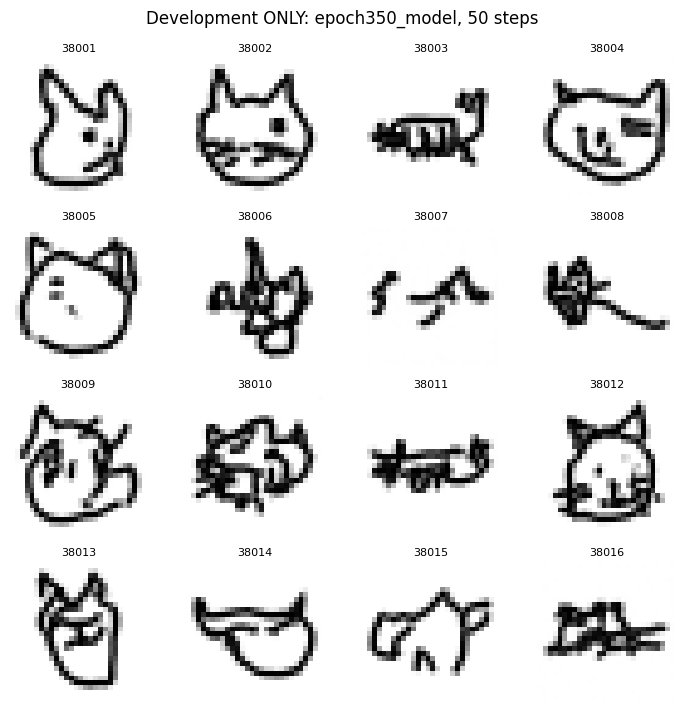

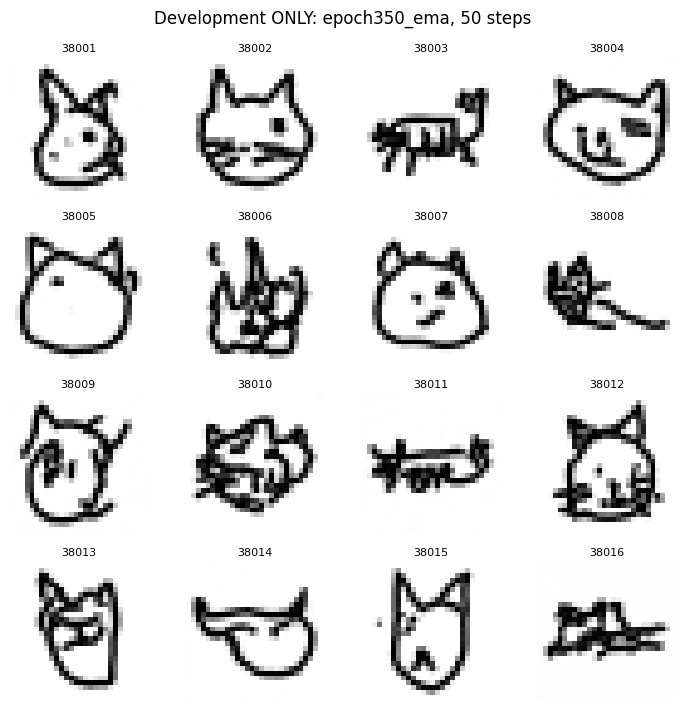

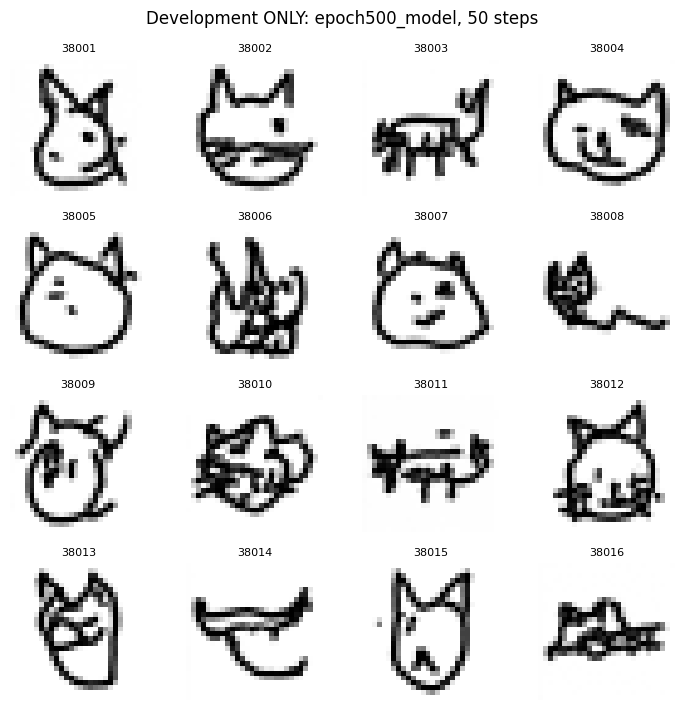

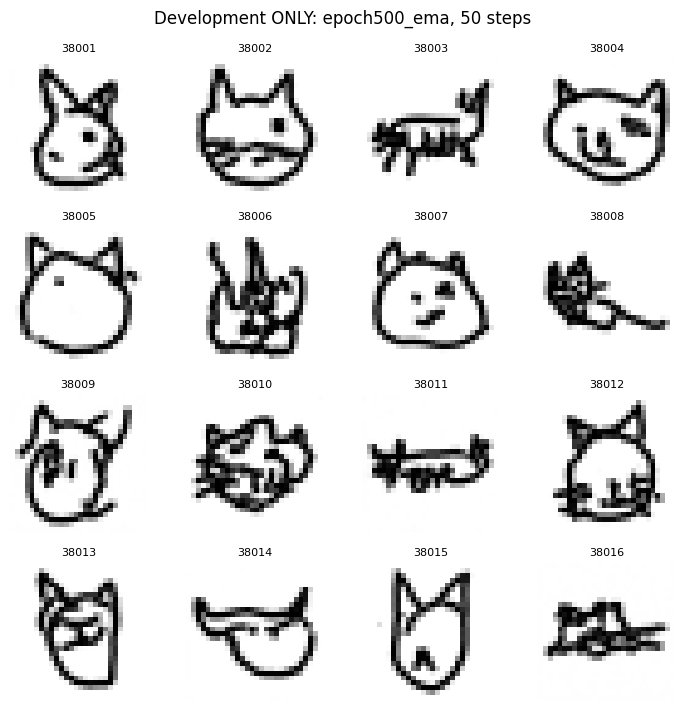

Proceed to the new, separate 64-seed evaluation. No checkpoint selection is based on these previews.


In [6]:
@torch.no_grad()
def euler_sample(network,initial_noise,steps):
    if steps<1:raise ValueError('Positive Euler steps required.')
    network.eval();x=initial_noise.clone()
    for k in range(steps):
        t=torch.full((len(x),),k/steps,device=x.device)
        x=x+network(x,t)/steps
    return x

def load_network(epoch,weight_kind='model'):
    path=SOURCE_PATH if epoch==SOURCE_EPOCH else RUN/f'checkpoint_epoch_{epoch}.pt'
    cp=torch.load(path,map_location='cpu',weights_only=True)
    if cp['epoch']!=epoch or cp['training_id']!=TRAINING_ID:raise ValueError('Checkpoint identity mismatch.')
    if epoch==SOURCE_EPOCH:
        if digest(path)!=EXPECTED_SOURCE_CHECKPOINT_SHA256:raise ValueError('Baseline checkpoint changed.')
        if weight_kind!='model':raise ValueError('No historical EMA checkpoint exists at epoch 250.')
    else:validate_continuation(cp,RUN_ID,SOURCE_EPOCH,BATCHES_PER_EPOCH)
    network=VelocityUNet().to(DEVICE);network.load_state_dict(cp[weight_kind]);return network.eval()

def seed_noise(seeds):
    return torch.cat([torch.randn(1,1,28,28,generator=torch.Generator().manual_seed(s)) for s in seeds])

def image_grid(images,path,title,labels,columns=4,show=False):
    if torch.is_tensor(images):images=images.detach().cpu().numpy()
    rows=math.ceil(len(images)/columns)
    fig,axes=plt.subplots(rows,columns,figsize=(columns*1.8,rows*1.8),squeeze=False)
    for i,ax in enumerate(axes.flat):
        ax.axis('off')
        if i<len(images):
            ax.imshow(np.clip((images[i].squeeze()+1)/2,0,1),cmap='gray_r',vmin=0,vmax=1,interpolation='nearest')
            ax.set_title(str(labels[i]),fontsize=8)
    fig.suptitle(title);fig.tight_layout();fig.savefig(path,dpi=150)
    if show:plt.show()
    plt.close(fig)

class ConstantVelocity(nn.Module):
    def forward(self,x,t):return torch.full_like(x,.25)
fixture=torch.zeros(2,1,28,28,device=DEVICE)
assert torch.allclose(euler_sample(ConstantVelocity(),fixture,20),fixture+.25,atol=1e-6)
print('Passed constant-velocity solver check.')
DEV=RUN/'development';DEV.mkdir(exist_ok=True)
for epoch in SAVE_EPOCHS:
    if not (RUN/f'checkpoint_epoch_{epoch}.pt').exists():continue
    for kind in ['model','ema']:
        name=f'epoch{epoch}_{kind}'
        network=load_network(epoch,kind)
        result=euler_sample(network,seed_noise(DEV_SEEDS).to(DEVICE),STEPS).cpu().numpy()
        if not np.isfinite(result).all():raise RuntimeError('Non-finite development samples.')
        np.save(DEV/f'{name}.npy',result)
        image_grid(result,DEV/f'{name}.png',f'Development ONLY: {name}, {STEPS} steps',DEV_SEEDS,show=True)
        del network
print('Proceed to the new, separate 64-seed evaluation. No checkpoint selection is based on these previews.')

## Cell 7 — Generate new matched outputs without revealing their labels
The same new noise seeds **39001–39064** are used for all three models. Five timing rounds randomise configuration order; each configuration is warmed up and GPU-synchronised. Timing excludes model loading, image saving and plotting. Compare timings only within this run. Ordinary and EMA models have the same number of sampling steps and network evaluations; there is no expected sampling-cost reduction from EMA.

Saved arrays are reused on resume, with hashes checked. The key and labelled arrays are available for reproducibility, but do not inspect their labels before completing the 192 ratings.

In [7]:
RAW=RUN/'raw_arrays';RAW.mkdir(exist_ok=True)
complete_path=RUN/'generation_complete.json'
checkpoint_hashes={'epoch250':digest(SOURCE_PATH),'epoch500':digest(RUN/f'checkpoint_epoch_{TARGET_EPOCH}.pt')}
if complete_path.exists():
    saved=json.loads(complete_path.read_text())
    if saved['protocol_sha256']!=digest(protocol_path) or saved['checkpoint_sha256']!=checkpoint_hashes:
        raise ValueError('Protocol or checkpoints changed after generation; recover the original files.')
    for name,_,_ in CONFIGS:
        p=RAW/f'{name}.npy'
        if digest(p)!=saved['array_sha256'][name]:raise ValueError('Saved generated array changed.')
        arr=np.load(p,allow_pickle=False)
        if arr.shape!=(64,1,28,28) or not np.isfinite(arr).all():raise ValueError('Unexpected generated array.')
    if digest(RUN/'timing_repeats.csv')!=saved['timing_sha256']:raise ValueError('Saved timing table changed.')
    if digest(RUN/'initial_noise.npy')!=saved['initial_noise_sha256']:raise ValueError('Saved initial noise changed.')
    print('Reusing saved arrays and timings. No regeneration.')
else:
    if (RUN/'human_ratings.csv').exists():
        prior=pd.read_csv(RUN/'human_ratings.csv',keep_default_na=False)
        if pd.to_numeric(prior.cat_score,errors='coerce').notna().any():
            raise ValueError('Rated outputs have no completion metadata; restore it rather than regenerating rated images.')
    initial_cpu=seed_noise(EVALUATION_SEEDS);initial=initial_cpu.to(DEVICE)
    np.save(RUN/'initial_noise.npy',initial_cpu.numpy())
    timing_rows=[];order_rng=np.random.default_rng(601052)
    for repeat in range(TIMING_REPEATS):
        for idx in order_rng.permutation(len(CONFIGS)):
            name,epoch,kind=CONFIGS[int(idx)]
            network=load_network(epoch,kind)
            euler_sample(network,initial[:INFERENCE_BATCH],STEPS);synchronize()
            started=time.perf_counter()
            parts=[euler_sample(network,initial[i:i+INFERENCE_BATCH],STEPS) for i in range(0,len(initial),INFERENCE_BATCH)]
            synchronize();elapsed=time.perf_counter()-started
            if repeat==0:
                result=torch.cat(parts).cpu().numpy()
                if result.shape!=(64,1,28,28) or not np.isfinite(result).all():raise RuntimeError('Invalid generated outputs.')
                np.save(RAW/f'{name}.npy',result)
            timing_rows.append({'configuration':name,'epoch':epoch,'weight_kind':kind,'steps':STEPS,
                                'nfe_per_image':STEPS,'repeat':repeat+1,'images':64,'batch_size':INFERENCE_BATCH,
                                'seconds_for_64':elapsed})
            del network,parts
        print(f'Timing round {repeat+1}/{TIMING_REPEATS} finished. Configuration labels remain concealed.')
    save_csv(RUN/'timing_repeats.csv',pd.DataFrame(timing_rows))
    save_json(complete_path,{'completed_utc':utc_now(),'protocol_sha256':digest(protocol_path),
        'checkpoint_sha256':checkpoint_hashes,'array_sha256':{name:digest(RAW/f'{name}.npy') for name,_,_ in CONFIGS},
        'timing_sha256':digest(RUN/'timing_repeats.csv'),'initial_noise_sha256':digest(RUN/'initial_noise.npy'),
        'versions':VERSIONS,'python':sys.version,'hardware':HARDWARE,'device':str(DEVICE)})

records=[{'configuration':name,'seed':seed,'array_index':i} for name,_,_ in CONFIGS for i,seed in enumerate(EVALUATION_SEEDS)]
order=np.random.default_rng(SHUFFLE_SEED).permutation(len(records))
key=pd.DataFrame([{'image_id':f'NEW_{j+1:03d}',**records[int(i)]} for j,i in enumerate(order)])
key_path=RUN/'configuration_key_DO_NOT_OPEN_UNTIL_SCORED.csv'
if key_path.exists():pd.testing.assert_frame_equal(pd.read_csv(key_path),key)
else:save_csv(key_path,key)
ratings_path=RUN/'human_ratings.csv'
if not ratings_path.exists():
    save_csv(ratings_path,pd.DataFrame({'image_id':key.image_id,'cat_score':'','notes':'','rater':'','rated_utc':''}))
arrays={name:np.load(RAW/f'{name}.npy',allow_pickle=False) for name,_,_ in CONFIGS}
BLIND=RUN/'blinded_grids';BLIND.mkdir(exist_ok=True)
for start in range(0,len(key),16):
    rows=key.iloc[start:start+16]
    images=np.stack([arrays[r.configuration][int(r.array_index)] for r in rows.itertuples()])
    image_grid(images,BLIND/f'page{start//16+1:02d}.png','Anonymous scoring booklet',rows.image_id.tolist())
print('192 matched outputs ready. Do not reveal the configuration key until scoring is complete.')

Timing round 1/5 finished. Configuration labels remain concealed.
Timing round 2/5 finished. Configuration labels remain concealed.
Timing round 3/5 finished. Configuration labels remain concealed.
Timing round 4/5 finished. Configuration labels remain concealed.
Timing round 5/5 finished. Configuration labels remain concealed.
192 matched outputs ready. Do not reveal the configuration key until scoring is complete.


## Cell 8 — Calibrate using 16 randomly selected real held-out drawings
Review these before rating. They are real category-labelled drawings, not examples selected to look good. Real cat labels do not guarantee human recognisability. Do not give generated images a lower score just because they are rough, and do not count an ambiguous animal as a clearly recognisable cat.

**0:** no identifiable animal. **1:** animal-like but ambiguous/incoherent. **2:** recognisable cat with coherent identifying structure; a rough head-only drawing can qualify. Pointy ears alone are insufficient. Use this same rule for every image and keep borderline notes. This single planned rating pass follows the earlier calibration feedback; it is not an independent replication of your previous rating passes.

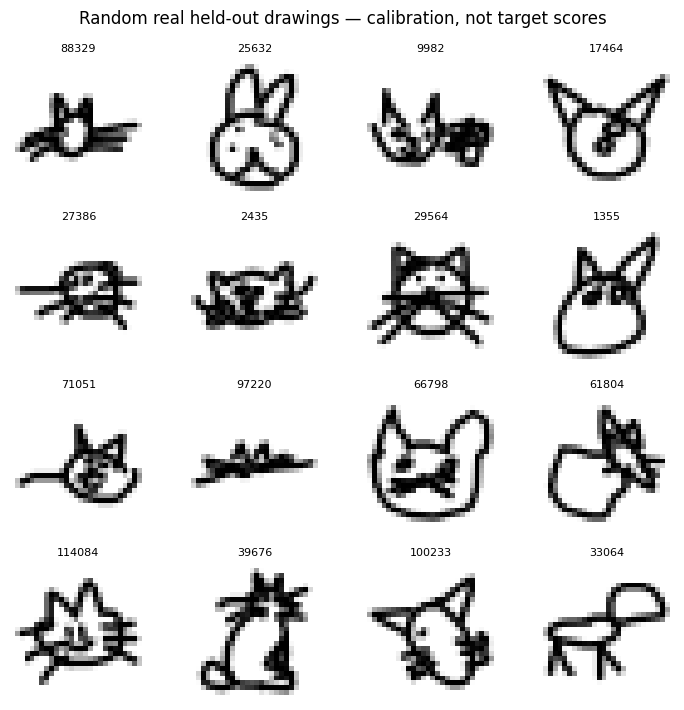

Apply the same rubric throughout. These examples have no assigned target scores.


In [8]:
calibration_positions=np.random.default_rng(601031).choice(len(eval_x),16,replace=False)
np.save(RUN/'calibration_heldout_positions.npy',calibration_positions)
image_grid(eval_x[calibration_positions],RUN/'calibration_real_heldout.png',
           'Random real held-out drawings — calibration, not target scores',
           manifest.iloc[eval_positions[calibration_positions]].source_row_index.tolist(),show=True)
save_json(RUN/'calibration_provenance.json',{'selection_seed':601031,'heldout_positions':calibration_positions.tolist(),
    'source_row_indices':manifest.iloc[eval_positions[calibration_positions]].source_row_index.tolist(),
    'source_sha256':source_hash,'manifest_sha256':manifest_digest,'rubric':RUBRIC,
    'prior_context':'Rater has seen previous results, calibrated reassessment, and separate development previews.'})
print('Apply the same rubric throughout. These examples have no assigned target scores.')

## Cell 9 — Score all 192 images; saves after every rating
**This is the only manual pause.** Select 0, 1 or 2, click **Save score**, then **Next**. Save and Next are separate to avoid accidental rapid-click rating errors. No default score is selected. Your name is prefilled, but every score must be chosen by you. Notes are optional.

Ratings resume at the first unscored image. Previous permits correction of an accidental entry; all save events are retained. Do not revise the rubric or rescore to improve the reported rate. Once all 192 are scored, rerun Cells 10–12. Run-all cannot wait for your clicks and may produce an incomplete progress export.

In [13]:
try:import ipywidgets as widgets
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable,'-m','pip','install','ipywidgets','-q'])
    import ipywidgets as widgets
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:pass
ratings=pd.read_csv(ratings_path,keep_default_na=False)
if ratings.image_id.tolist()!=key.image_id.tolist():raise ValueError('Rating IDs differ from the preserved configuration key.')
missing=pd.to_numeric(ratings.cat_score,errors='coerce').isna()
position={'i':int(np.flatnonzero(missing.to_numpy())[0]) if missing.any() else 0}
rater_box=widgets.Text(value='Sayuru Bopitiya',description='Rater:')
score_box=widgets.RadioButtons(options=[('0 — no animal',0),('1 — ambiguous animal',1),('2 — recognisable cat',2)],value=None)
notes_box=widgets.Textarea(description='Notes:',layout=widgets.Layout(width='600px',height='65px'))
status=widgets.HTML();image_output=widgets.Output()
save_button=widgets.Button(description='Save score',button_style='success')
previous_button=widgets.Button(description='Previous');next_button=widgets.Button(description='Next')
def show_current():
    i=position['i'];row=key.iloc[i];count=int(pd.to_numeric(ratings.cat_score,errors='coerce').notna().sum())
    already=str(ratings.at[i,'cat_score']).strip()!=''
    status.value=f'<b>{row.image_id}</b> · image {i+1}/192 · {count}/192 scored · previously rated: {already}'
    score_box.value=None;save_button.disabled=False;notes_box.value=str(ratings.at[i,'notes'])
    with image_output:
        clear_output(wait=True)
        fig,ax=plt.subplots(figsize=(3.7,3.7))
        ax.imshow(np.clip((arrays[row.configuration][int(row.array_index),0]+1)/2,0,1),cmap='gray_r',vmin=0,vmax=1,interpolation='nearest')
        ax.axis('off');plt.show();plt.close(fig)
def save_current(_):
    if score_box.value is None or not rater_box.value.strip():
        status.value='Choose a score and enter a rater name, then save.';return
    i=position['i'];timestamp=utc_now();old=str(ratings.at[i,'cat_score'])
    ratings.loc[i,['cat_score','notes','rater','rated_utc']]=[int(score_box.value),notes_box.value,rater_box.value.strip(),timestamp]
    save_csv(ratings_path,ratings)
    event={'saved_utc':timestamp,'image_id':str(ratings.at[i,'image_id']),'previous_score':old,
           'cat_score':int(score_box.value),'notes':notes_box.value,'rater':rater_box.value.strip()}
    with open(RUN/'rating_events.jsonl','a') as f:f.write(json.dumps(event)+'\n')
    count=int(pd.to_numeric(ratings.cat_score,errors='coerce').notna().sum())
    status.value=f'<b>Saved {ratings.at[i,"image_id"]}</b> · {count}/192 scored. Click Next.'
    if count==len(key):status.value+='<br><b>All images scored. Rerun Cells 10–12.</b>'
    save_button.disabled=True

def move(delta):
    position['i']=max(0,min(len(ratings)-1,position['i']+delta));show_current()
save_button.on_click(save_current)
previous_button.on_click(lambda _:move(-1));next_button.on_click(lambda _:move(1))
display(widgets.VBox([rater_box,status,image_output,score_box,notes_box,widgets.HBox([save_button,previous_button,next_button])]))
show_current()

## Cell 10 — Reveal results and decide whether the gain is substantial
Primary outcome: proportion scored 2. Wilson 95% intervals describe finite-seed uncertainty. Differences resample **whole matched seeds** 20,000 times, retaining the pairing. Positive training difference favours 500 raw over 250 raw; positive EMA difference favours 500 EMA over 500 raw. The additional EMA-versus-baseline contrast supports the practical stopping rule.

These are exploratory intervals conditional on one training trajectory and one rater, without multiple-comparison adjustment. They do not estimate training-seed or inter-rater uncertainty. An interval spanning zero is inconclusive; a degenerate bootstrap interval is not proof of population equivalence. Compare to the **new matched epoch-250 baseline**, not directly to the old 10/64 or 11/64 on different seeds/steps.

In [14]:
ANALYSIS_READY=False
frame=pd.read_csv(ratings_path,keep_default_na=False)
if pd.to_numeric(frame.cat_score,errors='coerce').isna().any():
    print(f'Only {pd.to_numeric(frame.cat_score,errors="coerce").notna().sum()}/192 scored. Finish Cell 9, then rerun Cells 10–12.')
else:
    merged=validate_ratings(frame,key)
    summaries=[]
    for name,epoch,kind in CONFIGS:
        g=merged[merged.configuration==name]
        if len(g)!=64:raise ValueError('Each configuration must contain exactly 64 rated seeds.')
        k=int((g.cat_score==2).sum());ci=binomtest(k,len(g)).proportion_ci(method='wilson')
        summaries.append({'configuration':name,'epoch':epoch,'weight_kind':kind,'steps':STEPS,
            'n':len(g),'score0_count':int((g.cat_score==0).sum()),'score1_count':int((g.cat_score==1).sum()),
            'recognisable_count':k,'recognisable_fraction':k/len(g),'wilson95_low':float(ci.low),
            'wilson95_high':float(ci.high),'mean_score':float(g.cat_score.mean())})
    summary=pd.DataFrame(summaries)
    wide=merged.pivot(index='seed',columns='configuration',values='cat_score').sort_index()
    if wide.index.tolist()!=EVALUATION_SEEDS or wide.isna().any().any():raise ValueError('Matched seed table is incomplete.')
    rows=[];per_seed=[]
    for label,a,b in [('extra_training','epoch500_raw','epoch250_raw'),('ema_at_500','epoch500_ema','epoch500_raw'),('ema_vs_baseline','epoch500_ema','epoch250_raw')]:
        av,bv=wide[a].to_numpy(),wide[b].to_numpy()
        for metric,x,y in [('recognisable_fraction',(av==2).astype(float),(bv==2).astype(float)),('mean_score',av,bv)]:
            rows.append({'comparison':label,'a':a,'b':b,'metric':metric,
                         **paired_difference(x,y,seed=BOOTSTRAP_SEED,repeats=BOOTSTRAP_REPEATS)})
        for seed,x,y in zip(EVALUATION_SEEDS,av,bv):per_seed.append({'comparison':label,'seed':seed,'a_score':int(x),'b_score':int(y),'difference':int(x-y)})
    comparisons=pd.DataFrame(rows)
    save_csv(RUN/'ratings_unblinded.csv',merged);save_csv(RUN/'quality_summary.csv',summary)
    save_csv(RUN/'paired_comparisons.csv',comparisons);save_csv(RUN/'paired_seed_scores.csv',pd.DataFrame(per_seed))
    timing_frame=pd.read_csv(RUN/'timing_repeats.csv')
    timing_summary=timing_frame.groupby('configuration').agg(median_seconds_for_64=('seconds_for_64','median'),
        std_seconds_for_64=('seconds_for_64','std'),repeats=('seconds_for_64','count')).reset_index()
    save_csv(RUN/'timing_summary.csv',timing_summary)
    candidates=comparisons[(comparisons.metric=='recognisable_fraction')&(comparisons.b=='epoch250_raw')]
    qualifying=candidates[(candidates.difference>=MAJOR_GAIN)&(candidates.ci95_low>0)]
    major=not qualifying.empty
    decision={'recorded_utc':utc_now(),'major_gain_margin':MAJOR_GAIN,'major_improvement_observed_by_working_rule':major,
              'qualifying_configurations':qualifying.a.tolist(),
              'next_action':'Use this follow-up in the report; no additional training is planned.' if major else 'Stop further training and proceed to the report; document limited recognisability and the bounded improvement attempt.',
              'scope':'Exploratory, fixed models, 64 matched seeds, one rater; not independent replication or a deployment claim.'}
    save_json(RUN/'experiment_decision.json',decision)
    save_json(RUN/'analysis_provenance.json',{'analysed_utc':utc_now(),'ratings_sha256':digest(ratings_path),
        'protocol_sha256':digest(protocol_path),'generation_metadata_sha256':digest(complete_path),
        'key_sha256':digest(key_path),'decision_sha256':digest(RUN/'experiment_decision.json'),'versions':VERSIONS})
    display(summary);display(comparisons);display(timing_summary)
    print('Working-rule assessment:',decision['major_improvement_observed_by_working_rule'])
    print(decision['next_action'])
    print('Personal training prediction:',protocol['student_prediction_training'] or '[not provided]')
    print('Personal EMA prediction:',protocol['student_prediction_ema'] or '[not provided]')
    print('No future improvement is guaranteed, even if this particular sample shows a gain.')
    ANALYSIS_READY=True

,configuration,epoch,weight_kind,steps,n,score0_count,score1_count,recognisable_count,recognisable_fraction,wilson95_low,wilson95_high,mean_score
0,epoch250_raw,250,model,50,64,24,36,4,0.06250,0.024571,0.149975,0.687500
1,epoch500_raw,500,model,50,64,26,36,2,0.03125,0.008612,0.106973,0.625000
2,epoch500_ema,500,ema,50,64,19,43,2,0.03125,0.008612,0.106973,0.734375


,comparison,a,b,metric,difference,ci95_low,ci95_high,improved_seeds,tied_seeds,worsened_seeds,degenerate_bootstrap
0,extra_training,epoch500_raw,epoch250_raw,recognisable_fraction,-0.031250,-0.093750,0.031250,1,60,3,False
1,extra_training,epoch500_raw,epoch250_raw,mean_score,-0.062500,-0.203125,0.078125,9,42,13,False
2,ema_at_500,epoch500_ema,epoch500_raw,recognisable_fraction,0.000000,-0.046875,0.046875,1,62,1,False
3,ema_at_500,epoch500_ema,epoch500_raw,mean_score,0.109375,0.000000,0.218750,11,49,4,False
4,ema_vs_baseline,epoch500_ema,epoch250_raw,recognisable_fraction,-0.031250,-0.078125,0.000000,0,62,2,False
5,ema_vs_baseline,epoch500_ema,epoch250_raw,mean_score,0.046875,-0.046875,0.140625,7,53,4,False


,configuration,median_seconds_for_64,std_seconds_for_64,repeats
0,epoch250_raw,0.621279,0.005266,5
1,epoch500_ema,0.620928,0.002573,5
2,epoch500_raw,0.619858,0.005044,5


Working-rule assessment: False
Stop further training and proceed to the report; document limited recognisability and the bounded improvement attempt.
Personal training prediction: [not provided]
Personal EMA prediction: [not provided]
No future improvement is guaranteed, even if this particular sample shows a gain.


## Cell 11 — Full grids, matched examples and nearest-training evidence
Runs only after scoring. All 64 outputs per model are retained. The first eight seeds in the matched figure are fixed, not chosen for quality. Nearest-training comparisons use clipped pixel MSE over **all 2,400 training originals**. White background, alignment and stroke thickness limit this measure. Nearest matches and diversity are descriptive diagnostics, not proof that the model has or has not memorised.

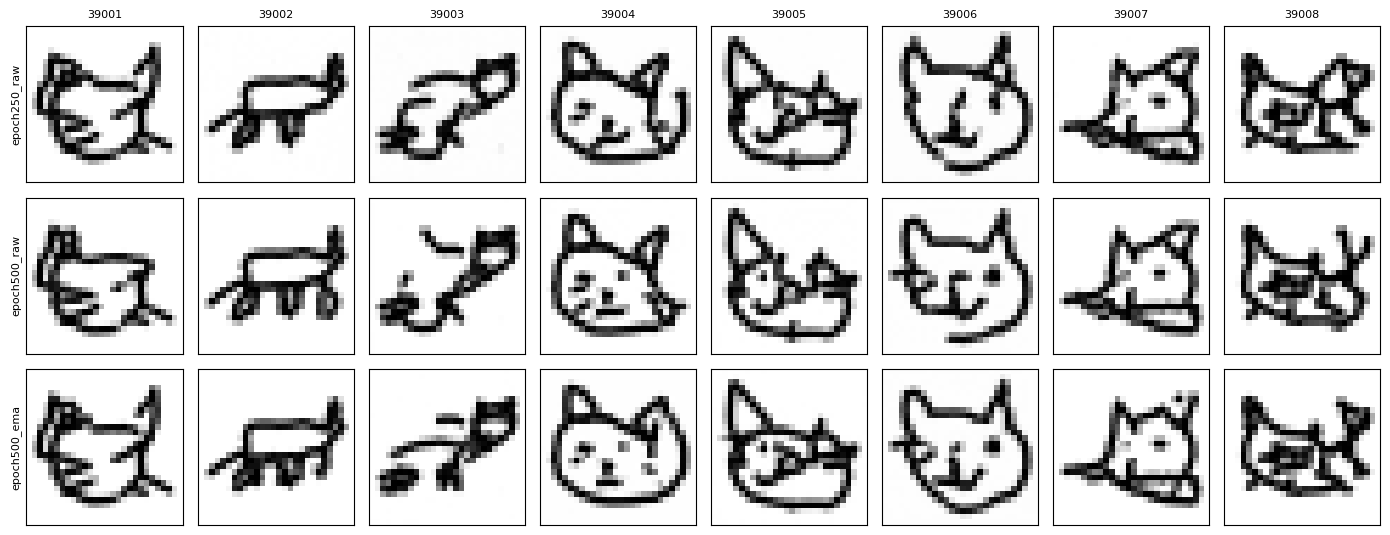

,configuration,pixel_mse_pairwise_diversity,nearest_train_mse_min,nearest_train_mse_mean,nearest_train_mse_max,fraction_raw_pixels_outside_training_range
0,epoch250_raw,0.739206,0.286919,0.433878,0.550813,0.175104
1,epoch500_raw,0.740784,0.233762,0.445249,0.588289,0.306063
2,epoch500_ema,0.729161,0.249339,0.420509,0.574045,0.235352


All labelled grids and nearest-training pairs saved. Review both recognisable outputs and failures.


In [15]:
def analysis_is_current():
    path=RUN/'analysis_provenance.json'
    if not path.exists() or not complete_path.exists():return False
    p=json.loads(path.read_text())
    return (p['ratings_sha256']==digest(ratings_path) and p['protocol_sha256']==digest(protocol_path)
            and p['generation_metadata_sha256']==digest(complete_path) and p['key_sha256']==digest(key_path))

if not analysis_is_current():
    print('Finish scoring and rerun Cell 10 first. Labelled evidence is not generated yet.')
else:
    FULL=RUN/'labelled_grids';FULL.mkdir(exist_ok=True)
    for name,epoch,kind in CONFIGS:
        for start in range(0,64,16):
            image_grid(arrays[name][start:start+16],FULL/f'{name}_page{start//16+1}.png',
                       f'{name}, {STEPS} Euler steps',EVALUATION_SEEDS[start:start+16])
    fig,axes=plt.subplots(3,8,figsize=(14,5.5))
    for row,(name,epoch,kind) in enumerate(CONFIGS):
        for col in range(8):
            ax=axes[row,col]
            ax.imshow(np.clip((arrays[name][col,0]+1)/2,0,1),cmap='gray_r',vmin=0,vmax=1,interpolation='nearest')
            ax.set_xticks([]);ax.set_yticks([])
            if row==0:ax.set_title(str(EVALUATION_SEEDS[col]),fontsize=8)
            if col==0:ax.set_ylabel(name,fontsize=8)
    fig.tight_layout();fig.savefig(RUN/'matched_first8.png',dpi=160);plt.show();plt.close(fig)
    real=train_x.numpy().clip(-1,1).reshape(len(train_x),-1).astype(np.float64)
    diagnostics=[];nn_rows=[];NN=RUN/'nearest_training';NN.mkdir(exist_ok=True)
    for name,epoch,kind in CONFIGS:
        fake=arrays[name].clip(-1,1).reshape(64,-1).astype(np.float64)
        distance=(fake**2).mean(axis=1)[:,None]+(real**2).mean(axis=1)[None,:]-2*(fake@real.T)/fake.shape[1]
        distance=np.maximum(distance,0);nearest=distance.argmin(axis=1);mins=distance.min(axis=1)
        within=(fake**2).mean(axis=1)[:,None]+(fake**2).mean(axis=1)[None,:]-2*(fake@fake.T)/fake.shape[1]
        diversity=float(np.maximum(within,0)[np.triu_indices(64,1)].mean())
        diagnostics.append({'configuration':name,'pixel_mse_pairwise_diversity':diversity,
            'nearest_train_mse_min':float(mins.min()),'nearest_train_mse_mean':float(mins.mean()),
            'nearest_train_mse_max':float(mins.max()),
            'fraction_raw_pixels_outside_training_range':float(((arrays[name]<-1)|(arrays[name]>1)).mean())})
        for i,(j,d) in enumerate(zip(nearest,mins)):
            nn_rows.append({'configuration':name,'seed':EVALUATION_SEEDS[i],'array_index':i,
                'nearest_train_position':int(j),'source_row_index':int(manifest.iloc[train_positions[j]].source_row_index),
                'pixel_mse_clipped':float(d)})
        for start in range(0,64,8):
            pictures=[];labels=[]
            for i in range(start,start+8):
                pictures.extend([arrays[name][i],train_x[int(nearest[i])].numpy()])
                labels.extend([f'Generated {EVALUATION_SEEDS[i]}',f'Train row {manifest.iloc[train_positions[int(nearest[i])]].source_row_index}'])
            image_grid(np.stack(pictures),NN/f'{name}_pairs{start//8+1}.png',
                       f'{name}: generated / nearest training pairs',labels,columns=4)
    save_csv(RUN/'image_diagnostics.csv',pd.DataFrame(diagnostics))
    save_csv(RUN/'nearest_training_matches.csv',pd.DataFrame(nn_rows))
    save_json(RUN/'evidence_provenance.json',{'created_utc':utc_now(),'analysis_sha256':digest(RUN/'analysis_provenance.json'),
        'diagnostics_sha256':digest(RUN/'image_diagnostics.csv'),'nearest_matches_sha256':digest(RUN/'nearest_training_matches.csv')})
    display(pd.DataFrame(diagnostics))
    print('All labelled grids and nearest-training pairs saved. Review both recognisable outputs and failures.')

## Cell 12 — Export results and checkpoints
Exports progress even when ratings are unfinished. **COMPLETE_FOR_REVIEW** requires epoch-500 weights, 192 valid ratings, current analysis and current labelled/nearest-training evidence. It means the experiment can be reviewed, not that the assignment or your personal reflection is complete.

Optional personal notes below are saved only if nonblank. Do not invent an independent check or a prediction. Your previous verified reflection stays separate. We will use this run to update the report and its limitations after reviewing the outputs. The ZIP excludes the public dataset and includes the original small epoch-250 checkpoint plus continuation checkpoints and a standalone inference script. Save this executed notebook separately from Colab.

In [16]:
MY_OBSERVATION_AND_DECISION=''  # Optional: your observation, a failure, and whether the attempt was worthwhile.
if MY_OBSERVATION_AND_DECISION.strip():
    save_json(RUN/'student_followup_notes.json',{'recorded_utc':utc_now(),'student_text':MY_OBSERVATION_AND_DECISION.strip(),
        'analysis_sha256':digest(RUN/'analysis_provenance.json') if analysis_is_current() else None})
# Copy the exact core helpers used in this notebook into the archive.
(RUN/'experiment_helpers.py').write_text("from pathlib import Path\nimport hashlib, os, shutil, zipfile\nimport numpy as np\nimport pandas as pd\nimport torch\n\ndef digest(path):\n    h=hashlib.sha256()\n    with open(path,'rb') as f:\n        for block in iter(lambda:f.read(1024*1024),b''):h.update(block)\n    return h.hexdigest()\n\ndef restore_verified_member(archive,basename,target,expected_hash):\n    target=Path(target);target.parent.mkdir(parents=True,exist_ok=True)\n    temporary=target.with_suffix(target.suffix+'.restore_tmp')\n    with zipfile.ZipFile(archive) as z:\n        for member in z.infolist():\n            p=Path(member.filename)\n            if p.is_absolute() or '..' in p.parts or p.name!=basename:continue\n            with z.open(member) as inp,open(temporary,'wb') as out:shutil.copyfileobj(inp,out)\n            if digest(temporary)==expected_hash:\n                os.replace(temporary,target)\n                return member.filename\n    temporary.unlink(missing_ok=True)\n    raise ValueError('The ZIP does not contain the verified original '+basename)\n\n@torch.no_grad()\ndef update_ema(ema,raw,decay):\n    if not 0<=decay<1:raise ValueError('EMA decay must lie in [0, 1).')\n    for average,current in zip(ema.parameters(),raw.parameters(),strict=True):\n        average.mul_(decay).add_(current,alpha=1-decay)\n    # GroupNorm needs no running-statistics update; copy the fixed frequency buffer.\n    for average,current in zip(ema.buffers(),raw.buffers(),strict=True):average.copy_(current)\n\ndef validate_continuation(checkpoint,run_id,source_epoch,batches_per_epoch):\n    epoch=checkpoint.get('epoch',-1)\n    if checkpoint.get('run_id')!=run_id or epoch<source_epoch:\n        raise ValueError('Checkpoint belongs to a different continuation experiment.')\n    if checkpoint.get('ema_start_epoch')!=source_epoch or 'ema' not in checkpoint:\n        raise ValueError('EMA history is missing; do not silently initialise a new average.')\n    if checkpoint.get('ema_updates')!=(epoch-source_epoch)*batches_per_epoch:\n        raise ValueError('EMA update count does not match the saved epoch.')\n    history=checkpoint.get('history',[])\n    if [row.get('epoch') for row in history]!=list(range(1,epoch+1)):\n        raise ValueError('Training history is incomplete or duplicated.')\n    if 'model' not in checkpoint or 'optimizer' not in checkpoint:\n        raise ValueError('Model or optimizer state is missing.')\n    return epoch\n\ndef validate_ratings(frame,key):\n    if len(frame)!=len(key) or frame.image_id.duplicated().any() or set(frame.image_id)!=set(key.image_id):\n        raise ValueError('Every anonymous ID must occur exactly once.')\n    scores=pd.to_numeric(frame.cat_score,errors='coerce')\n    if scores.isna().any() or not scores.isin([0,1,2]).all():\n        raise ValueError('Finish every rating with a score of 0, 1, or 2.')\n    if frame.rater.astype(str).str.strip().eq('').any():raise ValueError('Every rating needs a rater name.')\n    if pd.to_datetime(frame.rated_utc,utc=True,errors='coerce').isna().any():raise ValueError('Every rating needs a valid timestamp.')\n    result=frame.copy();result['cat_score']=scores.astype(int)\n    return result.merge(key,on='image_id',validate='one_to_one')\n\ndef paired_difference(a,b,seed=601051,repeats=20000):\n    a,b=np.asarray(a,dtype=float),np.asarray(b,dtype=float)\n    if a.shape!=b.shape or a.ndim!=1 or not len(a) or not np.isfinite(a-b).all():\n        raise ValueError('Finite, matched, nonempty vectors are required.')\n    d=a-b\n    indices=np.random.default_rng(seed).integers(0,len(d),size=(repeats,len(d)))\n    lo,hi=np.quantile(d[indices].mean(axis=1),[0.025,0.975])\n    return {'difference':float(d.mean()),'ci95_low':float(lo),'ci95_high':float(hi),\n            'improved_seeds':int((d>0).sum()),'tied_seeds':int((d==0).sum()),\n            'worsened_seeds':int((d<0).sum()),'degenerate_bootstrap':bool(np.ptp(d)==0)}\n")

NETWORK_SOURCE="class TimeEmbedding(nn.Module):\n    def __init__(self,dimension=64):\n        super().__init__()\n        self.register_buffer('frequencies',torch.exp(-math.log(10000)*torch.arange(dimension//2)/(dimension//2-1)))\n        self.mlp=nn.Sequential(nn.Linear(dimension,128),nn.SiLU(),nn.Linear(128,128))\n    def forward(self,t):\n        angles=t[:,None]*self.frequencies[None,:]*1000\n        return self.mlp(torch.cat([angles.sin(),angles.cos()],dim=1))\n\nclass TimeBlock(nn.Module):\n    def __init__(self,input_channels,output_channels):\n        super().__init__()\n        self.conv1=nn.Conv2d(input_channels,output_channels,3,padding=1)\n        self.norm1=nn.GroupNorm(8,output_channels)\n        self.time=nn.Linear(128,output_channels)\n        self.conv2=nn.Conv2d(output_channels,output_channels,3,padding=1)\n        self.norm2=nn.GroupNorm(8,output_channels)\n        self.skip=nn.Conv2d(input_channels,output_channels,1) if input_channels!=output_channels else nn.Identity()\n    def forward(self,x,time_embedding):\n        h=F.silu(self.norm1(self.conv1(x)))\n        h=h+self.time(time_embedding)[:,:,None,None]\n        h=self.norm2(self.conv2(F.silu(h)))\n        return F.silu(h+self.skip(x))\n\nclass VelocityUNet(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.time=TimeEmbedding()\n        self.input=nn.Conv2d(1,32,3,padding=1)\n        self.block28=TimeBlock(32,32)\n        self.down14=nn.Conv2d(32,64,4,stride=2,padding=1)\n        self.block14=TimeBlock(64,64)\n        self.down7=nn.Conv2d(64,128,4,stride=2,padding=1)\n        self.middle=TimeBlock(128,128)\n        self.up14=TimeBlock(128+64,64)\n        self.up28=TimeBlock(64+32,32)\n        self.output=nn.Conv2d(32,1,3,padding=1)\n    def forward(self,x,t):\n        embedding=self.time(t)\n        skip28=self.block28(self.input(x),embedding)\n        skip14=self.block14(self.down14(skip28),embedding)\n        h=self.middle(self.down7(skip14),embedding)\n        h=self.up14(torch.cat([F.interpolate(h,size=(14,14),mode='nearest'),skip14],dim=1),embedding)\n        h=self.up28(torch.cat([F.interpolate(h,size=(28,28),mode='nearest'),skip28],dim=1),embedding)\n        return self.output(h)"

inference_source='''# Reproduce a saved model: python inference.py --kind ema --epoch 500 --steps 50
from pathlib import Path
import argparse,math,hashlib
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
'''+NETWORK_SOURCE+'''
@torch.no_grad()
def main():
    p=argparse.ArgumentParser()
    p.add_argument('--epoch',type=int,choices=[250,350,500],default=500)
    p.add_argument('--kind',choices=['model','ema'],default='ema')
    p.add_argument('--steps',type=int,default=50)
    p.add_argument('--device',default='cuda' if torch.cuda.is_available() else 'cpu')
    a=p.parse_args()
    if a.steps<1:p.error('steps must be positive')
    if a.epoch==250 and a.kind!='model':p.error('No historical EMA exists at epoch 250; use --kind model')
    root=Path(__file__).resolve().parent
    path=root/'source_checkpoint_epoch250.pt' if a.epoch==250 else root/f'checkpoint_epoch_{a.epoch}.pt'
    cp=torch.load(path,map_location='cpu',weights_only=True)
    if cp['epoch']!=a.epoch:raise ValueError('Wrong epoch checkpoint')
    device=torch.device(a.device)
    if device.type=='cpu':torch.set_num_threads(2)
    network=VelocityUNet().to(device).eval();network.load_state_dict(cp[a.kind])
    seeds=list(range(39001,39065))
    initial=torch.cat([torch.randn(1,1,28,28,generator=torch.Generator().manual_seed(s)) for s in seeds])
    parts=[]
    for begin in range(0,64,16):
        x=initial[begin:begin+16].to(device)
        for k in range(a.steps):
            t=torch.full((len(x),),k/a.steps,device=device)
            x=x+network(x,t)/a.steps
        parts.append(x.cpu())
    result=torch.cat(parts).numpy()
    if not np.isfinite(result).all():raise RuntimeError('Non-finite samples')
    out=root/f'reproduced_epoch{a.epoch}_{a.kind}_steps{a.steps}.npy';np.save(out,result)
    print(out)
if __name__=='__main__':main()
'''
(RUN/'inference.py').write_text(inference_source)
(RUN/'README.txt').write_text('''COMP6010 C2 bounded continuation: Sayuru Bopitiya, 24071158.
Read export_status.json first. COMPLETE_FOR_REVIEW means experiment evidence is current; it is not assignment-completion certification.
Original dataset/network/AdamW settings unchanged. Source model+optimizer at epoch250; continue251-500.
EMA0.999 initialised from250, updated once after each new optimizer step. No historicalEMA before250.
Protocol: fresh final seeds39001-39064; separate development38001-38016; all models50Euler steps.
Checkpoints every5epochs; named350/500 include model, EMA, optimizer, update count, run identity and history.
Resume via Drive or upload this ZIP to the notebook when recovering a run in a new Drive folder.
training_history.csv contains original history plus continuation; old/new hardware times must be interpreted separately.
training_sessions.json records current execution environments and session wall times.
human_ratings.csv and rating_events.jsonl preserve the student's actual entries; no AI-assigned ratings.
quality_summary.csv uses Wilson95 intervals; paired_comparisons.csv uses20000 paired seed bootstrap resamples.
Intervals condition on one model trajectory and one rater, with no multiplicity adjustment.
A working major-gain rule (+10percentage points and paired lowerCI>0) was fixed before training; not an assignment requirement.
All generated arrays are unclipped; plots and pixel-distance diagnostics clip consistently to[-1,1].
Nearest matches use all2400 training drawings. PixelMSE cannot prove or disprove memorisation.
protocol.json records honest optional personal predictions or null missing values, plus separately labelled assistant hypotheses.
Student notes are optional. Existing evaluated prediction/reflection records remain separate and must accompany the final assignment.
Standalone inference: install torch,numpy; python inference.py --epoch500 --kindema --steps50 (use spaces: --epoch 500 --kind ema --steps 50).
A CPU is supported for inference; hardware/library changes may prevent bitwise reproduction.
The original checkpoint source hash and dataset/manifest hashes are validated by the notebook.
Public dataset is excluded. Save the executed notebook separately; this follow-up ZIP must join the full assignment supplement.
Sources: QuickDraw https://github.com/googlecreativelab/quickdraw-dataset (CCBY4.0);
FlowMatching Lipmanetal https://arxiv.org/abs/2210.02747;
EMA technique https://docs.pytorch.org/docs/stable/optim.html#weight-averaging-swa-and-ema;
Wilson interval https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats._result_classes.BinomTestResult.proportion_ci.html.
AI assistance: notebook continuation/EMA/recovery/evaluation code and development verification. Record actual visible tool/model label and personal checks in final AI-use log.
''')
analysis_current=analysis_is_current()
evidence_path=RUN/'evidence_provenance.json'
evidence_current=(analysis_current and evidence_path.exists() and
    json.loads(evidence_path.read_text())['analysis_sha256']==digest(RUN/'analysis_provenance.json'))
valid_ratings=False
try:
    validate_ratings(pd.read_csv(ratings_path,keep_default_na=False),key);valid_ratings=True
except ValueError:pass
final_path=RUN/f'checkpoint_epoch_{TARGET_EPOCH}.pt'
training_complete=final_path.exists()
if training_complete:
    cp=torch.load(final_path,map_location='cpu',weights_only=True)
    training_complete=validate_continuation(cp,RUN_ID,SOURCE_EPOCH,BATCHES_PER_EPOCH)==TARGET_EPOCH
complete=bool(training_complete and valid_ratings and analysis_current and evidence_current)
status={'status':'COMPLETE_FOR_REVIEW' if complete else 'INCOMPLETE_PROGRESS',
        'exported_utc':utc_now(),'training_complete':training_complete,'all_192_ratings_valid':valid_ratings,
        'analysis_current':analysis_current,'evidence_current':evidence_current,
        'assignment_report_and_personal_AI_log_still_need_update':True}
save_json(RUN/'export_status.json',status)
# last_checkpoint duplicates named500 at completion; keep named500, restore it as last on ZIP recovery.
archive=BASE/f'{RUN_NAME}_results.zip'
with zipfile.ZipFile(archive,'w',zipfile.ZIP_DEFLATED) as z:
    for path in sorted(RUN.rglob('*')):
        if not path.is_file() or path.suffix in ['.tmp','.restore_tmp']:continue
        if path.name=='last_checkpoint.pt' and training_complete:continue
        z.write(path,path.relative_to(RUN))
print('Export status:',status)
print('Results ZIP:',archive)
print('After scoring: rerun Cells 10–12. Save the executed .ipynb separately and upload both files for review.')
DOWNLOAD_RESULTS=True
if DOWNLOAD_RESULTS:
    try:
        from google.colab import files
        files.download(str(archive))
    except ImportError:print('Retrieve the archive from the displayed path.')

Export status: {'status': 'COMPLETE_FOR_REVIEW', 'exported_utc': '2026-10-01T19:05:40.939051+00:00', 'training_complete': True, 'all_192_ratings_valid': True, 'analysis_current': True, 'evidence_current': True, 'assignment_report_and_personal_AI_log_still_need_update': True}
Results ZIP: /content/drive/MyDrive/COMP6010/cat_500_ema_v1_results.zip
After scoring: rerun Cells 10–12. Save the executed .ipynb separately and upload both files for review.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>